## Access Kaggle
Serveral things you need to do to access Kaggle
- Sign in to Kaggle and join the competition called **BCI Homework 3 Kaggle Judge** (using the link we provide in the document)

- Create your own kaggle API token (in your account->API)
  
  <img src="https://i.imgur.com/Gia6TwE.png" alt="drawing" width="800"/>
- Upload API token (.json file) to Colab

   <img src="https://i.imgur.com/xjEXBYs.png" alt="drawing" width="200"/>

In [1]:
!mkdir -p /root/.kaggle
!mv kaggle.json /root/.kaggle
!chmod 600 /root/.kaggle/kaggle.json
!kaggle competitions list

ref                                                                                 deadline             category                reward  teamCount  userHasEntered  
----------------------------------------------------------------------------------  -------------------  ---------------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3       2026-04-15 23:59:00  Featured         2,207,152 Usd         86           False  
https://www.kaggle.com/competitions/hull-tactical-market-prediction                 2025-12-15 23:59:00  Featured           100,000 Usd       2506           False  
https://www.kaggle.com/competitions/vesuvius-challenge-surface-detection            2026-02-13 23:59:00  Research           100,000 Usd        159           False  
https://www.kaggle.com/competitions/google-tunix-hackathon                          2026-01-12 23:59:00  Featured           100,000 Usd         55           False  
https://ww

## Download Dataset from Kaggle

In [2]:
!kaggle competitions download -c 2025-nycu-bci-homework-3
!unzip -qq 2025-nycu-bci-homework-3.zip -d ./
!ls -l nycu-bci-homework-3/BCI_hw3_dataset

 84% 238M/282M [00:00<00:00, 766MB/s] 
100% 282M/282M [00:00<00:00, 590MB/s]
total 16
-rw-r--r-- 1 root root  269 Oct 15 14:35 data_detail.json
drwxr-xr-x 2 root root 4096 Nov 22 11:27 labeled_test
drwxr-xr-x 2 root root 4096 Nov 22 11:27 train
drwxr-xr-x 2 root root 4096 Nov 22 11:28 unlabeled_test


## Install Package (Optional)

In [3]:
!pip install torchinfo
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 80.9 MB/s eta 0:00:00


## Import Package and Library to Python Session

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
import torch.nn.functional as F

from matplotlib import pyplot as plt
from scipy.io import loadmat
from scipy.io import savemat
import numpy as np
import math
import time
import csv
import mne
import sys
import os

DATASET_DIR = "nycu-bci-homework-3/BCI_hw3_dataset/train"
DATASET_DIR_TEST = "nycu-bci-homework-3/BCI_hw3_dataset/labeled_test"
DATASET_DIR_EXAM = "nycu-bci-homework-3/BCI_hw3_dataset/unlabeled_test"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## EEG Model

### EEGNet

In [5]:
class EEGNet(nn.Module):
    """EEGNet model from Lawhern et al 2018.
    ... Parameters ............
    C: int
        Number of EEG input channels.
    N: int
        Number of EEG input time samples.
    nb_classes: int
        Number of classes to predict.
    kernLength: int
        Length of temporal convolution in first layer.
    F1, F2: int
        Number of temporal filters (F1) and number of pointwise filters (F2) to learn.
    D: int
        Number of spatial filters to learn within each temporal convolution.
    dropoutRate: float
        Dropout ratio.
    ... References ............
    https://arxiv.org/abs/1611.08024
    """
    def __init__(self, C, N, nb_classes, kernLength=64, F1=8, F2=16, D=2, dropoutRate=0.5):
        super(EEGNet, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, kernLength), padding="valid", bias=False),
            nn.BatchNorm2d(F1, eps=1e-3, momentum=0.99)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(
                F1, D * F1, (C, 1), groups=F1, bias=False
            ),
            nn.BatchNorm2d(D * F1, eps=1e-3, momentum=0.99),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropoutRate)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(
                D * F1, D * F1, (1, 16),
                padding=(0, 8), groups=D * F1, bias=False
            ),
            nn.Conv2d(D * F1, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2, eps=1e-3, momentum=0.99),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropoutRate)
        )

        fc_inSize = self.get_size(C, N)[1]
        self.classifier = nn.Linear(fc_inSize, nb_classes, bias=True)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size()[0], -1)
        x = self.classifier(x)
        return x

    def get_size(self, C, N):
        data = torch.ones((1, 1, C, N))
        x = self.conv1(data)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size()[0], -1)
        return x.size()


### SCCNet

In [15]:
# (Bonus) Optional TODO: Advanced SCCNet model without permutation layer
class SCCNet_v2(nn.Module):
    """Advanced SCCNet model without permutation layer.
    ... Parameters ............
    C: int
        Number of EEG input channels.
    N: int
        Number of EEG input time samples.
    nb_classes: int
        Number of classes to predict.
    Nu: int
        Number of spatial kernel.
    Nt: int
        Length of spatial kernel.
    Nc: int
        Number of spatial-temporal kernel.
    fs: float
        Sampling frequency of EEG input.
    dropoutRate: float
        Dropout ratio.
    ... References ............
    https://ieeexplore.ieee.org/document/8716937
    """
    def __init__(self, C, N, nb_classes, Nu=None, Nt=1, Nc=20, fs=1000.0, dropoutRate=0.5):
        super(SCCNet_v2, self).__init__()
        Nu = C if Nu is None else Nu
        # self.layer = ...

    def forward(self, x):
        return x


In [16]:
# TODO: finish the SCCNet
class SCCNet(nn.Module):
    """SCCNet model from Wei et al 2019.
    Note: Nc was misused in the paper to describe both the number of EEG input channels and the number of spatial-temporal kernel.
    Please refer to the following description to find the correspondence of the defined parameters and noataions in the paper.
    ... Parameters ............
    C: int
        Number of EEG input channels. (Same as the Nc mentioned in the first and second paragraphs of the paper section II.B)
    N: int
        Number of EEG input time samples.
    nb_classes: int
        Number of classes to predict.
    Nu: int
        Number of spatial kernel.
    Nt: int
        Length of spatial kernel.
    Nc: int
        Number of spatial-temporal kernel. (Same as the Nc mentioned in the third paragraph of the paper section II.B)
    fs: float
        Sampling frequency of EEG input.
    dropoutRate: float
        Dropout ratio.
    ... References ............
    https://ieeexplore.ieee.org/document/8716937
    """
    # You can only add extra argument to this function, do NOT remove the existed arguments
    # The model structure should be dynamic changed by the provided arguments,
    # There will be a score penalty if SCCNet structure is static
    def __init__(self, C, N, nb_classes, Nu=None, Nt=1, Nc=20, fs=1000.0, dropoutRate=0.5):
        super().__init__()
        Nu = C if Nu is None else Nu # Default spatial kernel number = num of channels
        ### TODO: construct the model layers, refer to paper ###
        # self.layer = ...
        ### --- First convolutional block (spatial filtering) ---
        self.conv_spatial = nn.Conv2d(
            in_channels=1,
            out_channels=Nu,
            kernel_size=(C, Nt),
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(Nu)

        ### -- Permutation layer ---
        # Swap dimension order (2,1,3)
        self.permute=Permute2d((0,2,1,3))

        ### ---Second convolutional block
        self.conv_spatiotemporal=nn.Conv2d(
            in_channels=1,
            out_channels=Nc,
            kernel_size=(Nu,12),
            bias=False
        )
        self.bn2=nn.BatchNorm2d(Nc)

        ### --Pooling and regularization ---
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout=nn.Dropout(dropoutRate)

        ### --Classification layer--
        self.classifier=nn.Linear(Nc,nb_classes)



    def forward(self, x):
        ### TODO: forwarding rule ###
        # ex. x = self.layer(x)
        # note. remember the square activation and log activation
        # --Block 1:spatial convolution--
        if x.dim()==3:
          x=x.unsqueeze(1)

        x=self.conv_spatial(x)
        x=self.bn1(x)
        x=x**2

        x=self.permute(x)

        # --Block 2:spatio-temporal convolution--
        x=self.conv_spatiotemporal(x)
        x=self.bn2(x)
        x=x**2
        x=self.dropout(x)

        #--Pooling--
        x=self.pool(x)
        x = torch.log(torch.clamp(x, min=1e-6))

        #--Flatten+Classifier--
        x=x.view(x.size(0),-1)
        x=self.classifier(x)


        return x

    def get_size(self):
        # Optional TODO: auto calculate fully-connected layer helper function
        with torch.no_grad():
          dummy = torch.zeros(1, 1, self.Nu, self.N)
          out = self.forward(dummy)
        return out.size()

class Permute2d(nn.Module):
    def __init__(self, shape):
        super().__init__()
        self.shape = shape

    def forward(self, x):
        return torch.permute(x, self.shape)

## Train

In [202]:
# config training scheme, mode, hyperparam
eegmodel = SCCNet # function alias, should be EEGNet, SCCNet, SCCNet_v2
kwargs = dict(fs=125.0,dropoutRate=0.5) # custom args for different EEG model
scheme = "easy"  # "all", "easy"
easy_list = ["03","07","08","01"]  #TODO: Modify this list!!! Put the easy subject id here ex. ["01", "02" ......]
epochs = 200
batch_size = 16
lr = 1e-3
savepath = "checkpoints"
os.makedirs(savepath, exist_ok=True)

subject_id = "04"

### load data(all)

In [203]:
# In this section, we need to create 2 dataloader, easy, all
mat_T = loadmat(os.path.join(DATASET_DIR, f"BCIC_S{subject_id}_T.mat"))
x_data, y_data = mat_T["x_train"], mat_T["y_train"].squeeze()
x_train = np.zeros((0, *x_data.shape[1:]), dtype=x_data.dtype)
y_train = np.zeros((0, ), dtype=y_data.dtype)
x_valid = np.zeros((0, *x_data.shape[1:]), dtype=x_data.dtype)
y_valid = np.zeros((0, ), dtype=y_data.dtype)
### for tra_all_loader and val_all_loader
for sid in [f"{i:02d}" for i in range(1, 10)]:
    if sid == subject_id:
        continue
    mat_T = loadmat(os.path.join(DATASET_DIR, f"BCIC_S{sid}_T.mat"))
    x_data, y_data = mat_T["x_train"], mat_T["y_train"].squeeze()

    for c in range(4):
        x_, y_ = x_data[y_data == c], y_data[y_data == c]
        x_train = np.append(x_train, x_[:54], axis=0)
        y_train = np.append(y_train, y_[:54], axis=0)
        x_valid = np.append(x_valid, x_[54:], axis=0)
        y_valid = np.append(y_valid, y_[54:], axis=0)


# numpy array to tensor
x_train = torch.from_numpy(x_train)
y_train = torch.from_numpy(y_train).long()
x_valid = torch.from_numpy(x_valid)
y_valid = torch.from_numpy(y_valid).long()

# tensor reshape for training
x_train = x_train.unsqueeze(1)
y_train = F.one_hot(y_train, 4)
x_valid = x_valid.unsqueeze(1)
y_valid = F.one_hot(y_valid, 4)

print("train: {}, {}".format(x_train.size(), y_train.size()))
print("valid: {}, {}".format(x_valid.size(), y_valid.size()))

# build training and validation dataloader
trainset = torch.utils.data.TensorDataset(x_train, y_train)
validset = torch.utils.data.TensorDataset(x_valid, y_valid)
tra_all_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
val_all_loader = torch.utils.data.DataLoader(validset, batch_size=batch_size, shuffle=True, num_workers=2)

train: torch.Size([1728, 1, 22, 562]), torch.Size([1728, 4])
valid: torch.Size([576, 1, 22, 562]), torch.Size([576, 4])


### load data (easy)

In [204]:
# In this section, we need to create 2 dataloader, easy, all
mat_T = loadmat(os.path.join(DATASET_DIR, f"BCIC_S{subject_id}_T.mat"))
x_data, y_data = mat_T["x_train"], mat_T["y_train"].squeeze()
x_train = np.zeros((0, *x_data.shape[1:]), dtype=x_data.dtype)
y_train = np.zeros((0, ), dtype=y_data.dtype)
x_valid = np.zeros((0, *x_data.shape[1:]), dtype=x_data.dtype)
y_valid = np.zeros((0, ), dtype=y_data.dtype)
### for tra_easy_loader and val_easy_loader
### TODO ###
### Create the data according to easy_list ###
for sid in easy_list:
    if sid == subject_id:
        continue
    mat_T = loadmat(os.path.join(DATASET_DIR, f"BCIC_S{sid}_T.mat"))
    x_data, y_data = mat_T["x_train"], mat_T["y_train"].squeeze()

    for c in range(4):
        x_, y_ = x_data[y_data == c], y_data[y_data == c]
        x_train = np.append(x_train, x_[:54], axis=0)
        y_train = np.append(y_train, y_[:54], axis=0)
        x_valid = np.append(x_valid, x_[54:], axis=0)
        y_valid = np.append(y_valid, y_[54:], axis=0)



# numpy array to tensor
x_train = torch.from_numpy(x_train)
y_train = torch.from_numpy(y_train).long()
x_valid = torch.from_numpy(x_valid)
y_valid = torch.from_numpy(y_valid).long()

# tensor reshape for training
x_train = x_train.unsqueeze(1)
y_train = F.one_hot(y_train, 4)
x_valid = x_valid.unsqueeze(1)
y_valid = F.one_hot(y_valid, 4)

print("train: {}, {}".format(x_train.size(), y_train.size()))
print("valid: {}, {}".format(x_valid.size(), y_valid.size()))

# build training and validation dataloader
trainset = torch.utils.data.TensorDataset(x_train, y_train)
validset = torch.utils.data.TensorDataset(x_valid, y_valid)
tra_easy_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
val_easy_loader = torch.utils.data.DataLoader(validset, batch_size=batch_size, shuffle=True, num_workers=2)

train: torch.Size([864, 1, 22, 562]), torch.Size([864, 4])
valid: torch.Size([288, 1, 22, 562]), torch.Size([288, 4])


### training stage

In [205]:
# train an epoch, evaluate an epoch
# if you are familiar with Pytorch, you CAN custom these function
# such as adding the lr_scheduler to optimize the training progress

def train_an_epoch(model, data_loader, loss_fn, optimizer):
    model.train()

    a, b = 0, 0  # hit sample, total sample
    epoch_loss = np.zeros((len(data_loader), ))
    for i, (x_batch, y_batch) in enumerate(data_loader):
        x_batch, y_batch = x_batch.to(device, dtype=torch.float), y_batch.to(device, dtype=torch.float)
        ### TODO ###
        # TODO: zero grad optimizer
        optimizer.zero_grad()
        output = model(x_batch)# TODO: get model prediction
        loss = loss_fn(output, y_batch)# TODO: calc loss
        # TODO: back propagation
        loss.backward()
        # TODO: step the optimizer
        optimizer.step()

        epoch_loss[i] = loss.item()
        b += y_batch.size(0)
        a += torch.sum(y_batch.argmax(dim=1) == output.argmax(dim=1)).item()
    return epoch_loss.mean(), a / b  # return the loss and acc

def evalate_an_epoch(model, data_loader, loss_fn):
    model.eval()
    a, b = 0, 0 # hit sample, total sample
    epoch_loss = np.zeros((len(data_loader), ))
    for i, (x_batch, y_batch) in enumerate(data_loader):
        x_batch, y_batch = x_batch.to(device, dtype=torch.float), y_batch.to(device, dtype=torch.float)
        ### TODO ###
        output = model(x_batch)# TODO: get model prediction
        loss = loss_fn(output, y_batch)# TODO: calc loss

        epoch_loss[i] = loss.item()
        b += y_batch.size(0)
        a += torch.sum(y_batch.argmax(dim=1) == output.argmax(dim=1)).item()
    return epoch_loss.mean(), a / b  # return the loss and acc


In [206]:
model = eegmodel(x_train.size(2), x_train.size(3), 4, **kwargs).to(device)
loss_fn = nn.CrossEntropyLoss()  # loss function, can be modified
opt_fn = torch.optim.Adam(model.parameters(), lr=lr)  # optimizer, CAN be modified
# sche_fn = torch.optim.lr_scheduler.<???> # optional

# dump the model structure
summary(model, input_size=(batch_size, *list(x_train.size()[1:])))

Layer (type:depth-idx)                   Output Shape              Param #
SCCNet                                   [16, 4]                   --
├─Conv2d: 1-1                            [16, 22, 1, 562]          484
├─BatchNorm2d: 1-2                       [16, 22, 1, 562]          44
├─Permute2d: 1-3                         [16, 1, 22, 562]          --
├─Conv2d: 1-4                            [16, 20, 1, 551]          5,280
├─BatchNorm2d: 1-5                       [16, 20, 1, 551]          40
├─Dropout: 1-6                           [16, 20, 1, 551]          --
├─AdaptiveAvgPool2d: 1-7                 [16, 20, 1, 1]            --
├─Linear: 1-8                            [16, 4]                   84
Total params: 5,932
Trainable params: 5,932
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 50.90
Input size (MB): 0.79
Forward/backward pass size (MB): 5.99
Params size (MB): 0.02
Estimated Total Size (MB): 6.80

In [208]:
# if you are familiar with Pytorch, you CAN customize the following training loop
## TODO ##
curriculum_learning = True # True when curriculum learning / False when normal SI training scheme or normal SI+FT training scheme
best_val_acc=0
if curriculum_learning:
    hist = dict(
        loss=np.zeros((epochs, )), val_loss=np.zeros((epochs, )),
        acc=np.zeros((epochs, )), val_acc=np.zeros((epochs, ))
    )
    clock_ini = time.time()
    ### TODO : Modify the loader according to your curriculum training scheme ###
    ### ex. tra_all_loader, val_all_loader, tra_easy_loader, val_easy_loader
    tra_loader = tra_all_loader
    val_loader = val_all_loader
    for ep in range(int(epochs/2)):
        loss, acc = train_an_epoch(model, tra_loader, loss_fn, opt_fn)
        loss, acc = evalate_an_epoch(model, tra_loader, loss_fn)
        val_loss, val_acc = evalate_an_epoch(model, val_loader, loss_fn)
        print("Epoch {}: loss={:.4f}, acc={:.4f}, val_loss={:.4f}, val_acc={:.4f}".format(ep, loss, acc, val_loss, val_acc))
        hist["loss"][ep] = loss
        hist["acc"][ep] = acc
        hist["val_loss"][ep] = val_loss
        hist["val_acc"][ep] = val_acc
    ### TODO
    ### ex. tra_all_loader, val_all_loader, tra_easy_loader, val_easy_loader
    tra_loader = tra_easy_loader
    val_loader = val_easy_loader
    for ep in range(int(epochs/2)):
        loss, acc = train_an_epoch(model, tra_loader, loss_fn, opt_fn)
        loss, acc = evalate_an_epoch(model, tra_loader, loss_fn)
        val_loss, val_acc = evalate_an_epoch(model, val_loader, loss_fn)
        if val_acc>best_val_acc:
          best_val_acc=val_acc
          best_epoch=ep

          checkpoint = dict(
            epoch=ep,
            state_dict=model.state_dict(),
            loss=loss,
            val_loss=val_loss,
            val_acc=val_acc
          )
          torch.save(checkpoint,os.path.join(savepath, f"SCCNet-sub4-AtoE.pth"))  # save only once
        print("Epoch {}: loss={:.4f}, acc={:.4f}, val_loss={:.4f}, val_acc={:.4f}".format(ep+int(epochs/2), loss, acc, val_loss, val_acc))
        hist["loss"][ep+int(epochs/2)] = loss
        hist["acc"][ep+int(epochs/2)] = acc
        hist["val_loss"][ep+int(epochs/2)] = val_loss
        hist["val_acc"][ep+int(epochs/2)] = val_acc


        if True:
            checkpoint = dict(epoch=-1, state_dict=model.state_dict(), loss=loss, val_loss=val_loss)
            torch.save(checkpoint, os.path.join(savepath, f"Scheme13-ep{ep}.pth"))
    print("time spend: {:.2f} sec".format(time.time() - clock_ini))

else:
    hist = dict(
        loss=np.zeros((epochs, )), val_loss=np.zeros((epochs, )),
        acc=np.zeros((epochs, )), val_acc=np.zeros((epochs, ))
    )
    clock_ini = time.time()
    for ep in range(epochs):
        loss, acc = train_an_epoch(model, tra_loader, loss_fn, opt_fn)
        loss, acc = evalate_an_epoch(model, tra_loader, loss_fn)
        val_loss, val_acc = evalate_an_epoch(model, val_loader, loss_fn)
        print("Epoch {}: loss={:.4f}, acc={:.4f}, val_loss={:.4f}, val_acc={:.4f}".format(ep, loss, acc, val_loss, val_acc))
        hist["loss"][ep] = loss
        hist["acc"][ep] = acc
        hist["val_loss"][ep] = val_loss
        hist["val_acc"][ep] = val_acc

        if True:
            checkpoint = dict(epoch=-1, state_dict=model.state_dict(), loss=loss, val_loss=val_loss)
            torch.save(checkpoint, os.path.join(savepath, f"TORCH_MODEL_NAME-ep{ep}.pth"))
    print("time spend: {:.2f} sec".format(time.time() - clock_ini))

Epoch 0: loss=1.3380, acc=0.3414, val_loss=1.3763, val_acc=0.3160
Epoch 1: loss=1.3294, acc=0.3495, val_loss=1.3797, val_acc=0.3108
Epoch 2: loss=1.3272, acc=0.3715, val_loss=1.3578, val_acc=0.3160
Epoch 3: loss=1.3051, acc=0.3825, val_loss=1.3464, val_acc=0.3264
Epoch 4: loss=1.3029, acc=0.3987, val_loss=1.3446, val_acc=0.3750
Epoch 5: loss=1.3087, acc=0.3750, val_loss=1.3529, val_acc=0.3490
Epoch 6: loss=1.2817, acc=0.4300, val_loss=1.3252, val_acc=0.3767
Epoch 7: loss=1.2738, acc=0.4207, val_loss=1.3245, val_acc=0.3872
Epoch 8: loss=1.2817, acc=0.3866, val_loss=1.3366, val_acc=0.3368
Epoch 9: loss=1.2898, acc=0.3883, val_loss=1.3379, val_acc=0.3368
Epoch 10: loss=1.2643, acc=0.4334, val_loss=1.3228, val_acc=0.3802
Epoch 11: loss=1.2479, acc=0.4479, val_loss=1.3084, val_acc=0.4132
Epoch 12: loss=1.2449, acc=0.4282, val_loss=1.3176, val_acc=0.3594
Epoch 13: loss=1.2397, acc=0.4635, val_loss=1.3123, val_acc=0.3733
Epoch 14: loss=1.2364, acc=0.4502, val_loss=1.3115, val_acc=0.3889
Epoch

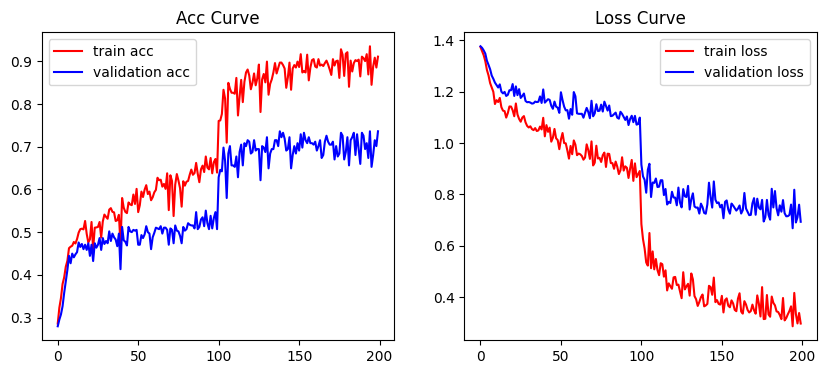

In [ ]:
# Acc curve, Loss curve
plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
plt.title("Acc Curve")
plt.plot(hist["acc"], color="red", label="train acc")
plt.plot(hist["val_acc"], color="blue", label="validation acc")
plt.legend()
plt.subplot(1, 2, 2)
plt.title("Loss Curve")
plt.plot(hist["loss"], color="red", label="train loss")
plt.plot(hist["val_loss"], color="blue", label="validation loss")
plt.legend()
plt.show()

### fine-tuning (SI+FT)

In [213]:
### TODO: build the fine-tuning dataloader ###
mat_T=loadmat(os.path.join(DATASET_DIR, f"BCIC_S{subject_id}_T.mat"))
x_data, y_data=mat_T["x_train"], mat_T["y_train"].squeeze()

# Training: first 54 per class (session 1)
ft_x_train = np.zeros((0, *x_data.shape[1:]), dtype=x_data.dtype)
ft_y_train = np.zeros((0, ), dtype=y_data.dtype)

# Validation: the rest (still session 1) – optional
ft_x_valid = np.zeros((0, *x_data.shape[1:]), dtype=x_data.dtype)
ft_y_valid = np.zeros((0, ), dtype=y_data.dtype)

for c in range(4):  # 4 classes
    x_c = x_data[y_data == c]
    y_c = y_data[y_data == c]
    ft_x_train = np.append(ft_x_train, x_c[:54], axis=0)
    ft_y_train = np.append(ft_y_train, y_c[:54], axis=0)
    ft_x_valid = np.append(ft_x_valid, x_c[54:], axis=0)
    ft_y_valid = np.append(ft_y_valid, y_c[54:], axis=0)

# Tensor conversion
ft_x_train = torch.from_numpy(ft_x_train).unsqueeze(1)    # [B,1,C,N]
ft_y_train = torch.from_numpy(ft_y_train).long()

ft_x_valid = torch.from_numpy(ft_x_valid).unsqueeze(1)
ft_y_valid = torch.from_numpy(ft_y_valid).long()

print("FT Train:", ft_x_train.size(), ft_y_train.size())
print("FT Valid:", ft_x_valid.size(), ft_y_valid.size())


# Build fine-tune dataloaders
ft_trainset=torch.utils.data.TensorDataset(ft_x_train,ft_y_train)
ft_validset=torch.utils.data.TensorDataset(ft_x_valid,ft_y_valid)
ft_train_loader = torch.utils.data.DataLoader(ft_trainset,batch_size=batch_size, shuffle=True)
ft_valid_loader = torch.utils.data.DataLoader(ft_validset,batch_size=batch_size, shuffle=False)


# load pre-trained model
### TODO ###
ep_num = best_epoch# TODO: the pre-trained epoch you want to tuning

model_path = os.path.join(savepath, "SCCNet-sub4-AtoE.pth")
checkpoint = torch.load(model_path, map_location="cpu", weights_only=False)  # load .pth
model.load_state_dict(checkpoint["state_dict"])  # set model weight

# # Optional: lock pre-trained weight
for param in model.parameters():
  param.requires_grad = False
for param in model.classifier.parameters():
  param.requires_grad = True
### TODO: fine-tuning training loop ###
loss_fn = nn.CrossEntropyLoss()

#optimizer = torch.optim.Adam(model.parameters(), lr=lr)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-4
)

ft_epochs=30
best_acc=0

for ep in range(1,ft_epochs+1):
  model.train()
  total_loss = 0.0
  correct = 0
  total = 0

  for x_batch, y_batch in ft_train_loader:
      x_batch = x_batch.to(device, dtype=torch.float32)
      y_batch = y_batch.to(device, dtype=torch.long)

      optimizer.zero_grad()
      output = model(x_batch)
      loss = loss_fn(output, y_batch)
      loss.backward()
      optimizer.step()

      total_loss += loss.item()
      preds = output.argmax(dim=1)
      correct += (preds == y_batch).sum().item()
      total += y_batch.size(0)

  train_loss = total_loss / len(ft_train_loader)
  train_acc = correct / total if total > 0 else 0.0

  # ====== VALIDATION (fine-tuning) ======
  model.eval()
  val_total_loss = 0.0
  val_correct = 0
  val_total = 0

  with torch.no_grad():
      for x_batch, y_batch in ft_valid_loader:
          x_batch = x_batch.to(device, dtype=torch.float32)
          y_batch = y_batch.to(device, dtype=torch.long)

          output = model(x_batch)
          loss = loss_fn(output, y_batch)

          val_total_loss += loss.item()
          preds = output.argmax(dim=1)
          val_correct += (preds == y_batch).sum().item()
          val_total += y_batch.size(0)

  val_loss = val_total_loss / len(ft_valid_loader)
  val_acc = val_correct / val_total if val_total > 0 else 0.0

  print(f"[FT][Sub {subject_id}] epoch {ep}/{ft_epochs} "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f}, "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}")

  # ====== SAVE BEST FT MODEL ======
  if val_acc > best_acc:
    best_acc = val_acc
    ft_best_ep=ep
    checkpoint = {
        "epoch": ep,
        "state_dict": model.state_dict()
    }
    torch.save(
        checkpoint,
        os.path.join(savepath, f"FT-SCCNet-sub4-AtoE.pth")
    )


FT Train: torch.Size([216, 1, 22, 562]) torch.Size([216])
FT Valid: torch.Size([72, 1, 22, 562]) torch.Size([72])
[FT][Sub 04] epoch 1/30 train_loss=1.5718, train_acc=0.319, val_loss=1.6400, val_acc=0.306
[FT][Sub 04] epoch 2/30 train_loss=1.5157, train_acc=0.356, val_loss=1.5285, val_acc=0.319
[FT][Sub 04] epoch 3/30 train_loss=1.4487, train_acc=0.343, val_loss=1.4919, val_acc=0.292
[FT][Sub 04] epoch 4/30 train_loss=1.5400, train_acc=0.338, val_loss=1.4682, val_acc=0.292
[FT][Sub 04] epoch 5/30 train_loss=1.5307, train_acc=0.333, val_loss=1.4734, val_acc=0.306
[FT][Sub 04] epoch 6/30 train_loss=1.5360, train_acc=0.347, val_loss=1.4992, val_acc=0.319
[FT][Sub 04] epoch 7/30 train_loss=1.4939, train_acc=0.366, val_loss=1.4998, val_acc=0.306
[FT][Sub 04] epoch 8/30 train_loss=1.5200, train_acc=0.366, val_loss=1.4948, val_acc=0.306
[FT][Sub 04] epoch 9/30 train_loss=1.4648, train_acc=0.380, val_loss=1.4722, val_acc=0.306
[FT][Sub 04] epoch 10/30 train_loss=1.5474, train_acc=0.352, val_lo

## Test

In [218]:
# load pre-trained model
#best_epoch = # TODO: determine the `BEST` epoch
#print("best epoch:", best_epoch)
#test_model_path = os.path.join(savepath, "{}-ep{}.pth".format("Scheme13", best_epoch))
#test_model_path = os.path.join(savepath, "EEGNet-1.pth")
test_model_path = os.path.join(savepath, "SCCNet-sub4-EtoA.pth")
checkpoint = torch.load(test_model_path, map_location="cpu", weights_only=False)  # load .pth
model.load_state_dict(checkpoint["state_dict"])  # set model weight

# testing on subject S01 test (E) session
mat = loadmat(os.path.join(DATASET_DIR_TEST, f"BCIC_S02_E.mat"))
x, y = mat["x_test"], mat["y_test"].squeeze()
x = torch.from_numpy(x)
y = torch.from_numpy(y).long()
x = x.unsqueeze(1)
y = F.one_hot(y, 4)

print("test: {}, {}".format(x.size(), y.size()))

testset = torch.utils.data.TensorDataset(x, y)
test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)
evalate_an_epoch(model, test_loader, loss_fn)

test: torch.Size([288, 1, 22, 562]), torch.Size([288, 4])


(np.float64(1.4361883733007643), 0.3541666666666667)

In [53]:
# If y is one-hot [B, 4], convert to indices [B]
if y.dim() == 2:
    y = y.argmax(dim=1)

print("test:", x.size(), y.size())

testset = torch.utils.data.TensorDataset(x, y)
test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)


test: torch.Size([288, 1, 22, 562]) torch.Size([288])


In [54]:
# Confusion matrix
test_model_path = os.path.join(savepath, "EEGNet-sub3-EtoA.pth")
checkpoint = torch.load(test_model_path, map_location="cpu", weights_only=False)  # load .pth
model.load_state_dict(checkpoint["state_dict"])
model.eval()

EEGNet(
  (conv1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=valid, bias=False)
    (1): BatchNorm2d(8, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
  )
  (conv2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(22, 1), stride=(1, 1), groups=8, bias=False)
    (1): BatchNorm2d(16, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (4): Dropout(p=0.5, inplace=False)
  )
  (conv3): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): Dropout(p=0.5, inplace=False)
  )
  (classifier): Linear(in_features=240, out_featur

In [55]:
all_preds = []
all_labels = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device, dtype=torch.float32)
        y_batch = y_batch.to(device, dtype=torch.long)

        outputs = model(x_batch)        # [B,4]
        preds = outputs.argmax(dim=1)   # [B]

        all_preds.append(preds.cpu())
        all_labels.append(y_batch.cpu())

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()


<Figure size 600x500 with 0 Axes>

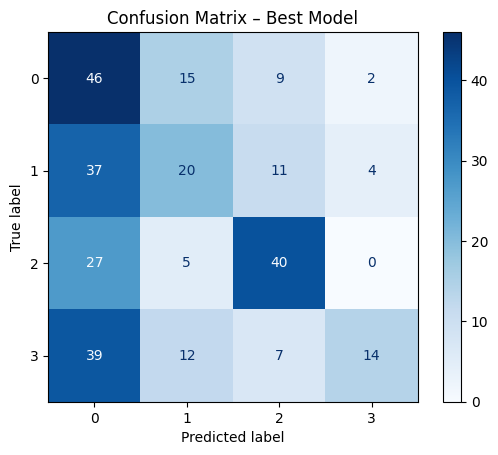

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6,5))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Best Model")
plt.show()


## Analyzing
You need to do some further analysis including
- confusion matrix,
- topographic maps for spatial kernel weights in SCCNet

You need to do these on your own in this section

Loaded SCCNet from: checkpoints/SCCNet-sub4-EtoA.pth
Raw conv_spatial weight shape: torch.Size([22, 1, 22, 1])
Spatial weights shape: (22, 22)
MNE info & montage ready.


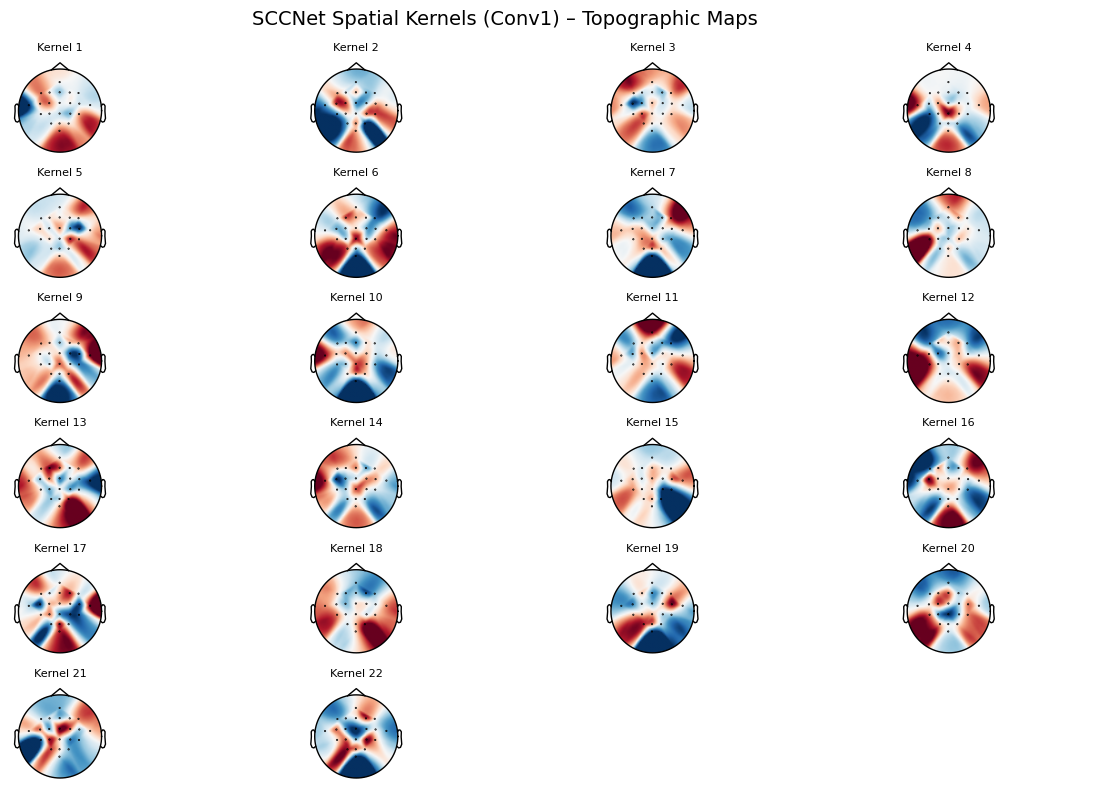

In [222]:
# mne doc: https://mne.tools/stable/python_reference.html
# "data_detail.json" in BCI_hw3_dataset/ provides you with all channel names in this dataset. It will help you to plot a topoplot.
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.viz import plot_topomap

C = 22
N = 562
nb_classes = 4

device = "cpu"
model = SCCNet(C=C, N=N, nb_classes=nb_classes).to(device)

# load the best SCCNet model
best_model_path = os.path.join(savepath, "SCCNet-sub4-EtoA.pth")

checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["state_dict"])
model.eval()
print("Loaded SCCNet from:", best_model_path)

# --- 抽出第一層空間 kernel 權重 ---

# conv_spatial: Conv2d(1, Nu, (C, Nt), bias=False)
w = model.conv_spatial.weight.data.clone().cpu()  # shape: [Nu, 1, C, Nt]
print("Raw conv_spatial weight shape:", w.shape)

Nu = w.shape[0]
C_from_weight = w.shape[2]
assert C_from_weight == C, f"Channel number mismatch: {C_from_weight} vs {C}"

# 若 Nt = 1：取 w[:, 0, :, 0] → [Nu, C]
# 若 Nt > 1：可以對最後一維做平均
if w.shape[-1] == 1:
    spatial_weights = w[:, 0, :, 0]    # [Nu, C]
else:
    spatial_weights = w[:, 0, :, :].mean(dim=-1)  # [Nu, C]

spatial_weights = spatial_weights.numpy()  # to numpy
print("Spatial weights shape:", spatial_weights.shape)  # (Nu, 22)

# --- 建立 MNE info + montage ---

ch_names = ["Fz", "FC3", "FC1", "FCz", "FC2", "FC4",
            "T7", "C3", "C1", "Cz", "C2", "C4", "T8",
            "CP3", "CP1", "CPz", "CP2", "CP4",
            "P1", "Pz", "P2", "POz"]

assert len(ch_names) == C, "Electrode list length != C"

sfreq = 125.0

ch_types = ['eeg'] * C
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)

# 使用標準 10-20 脑圖座標
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)

print("MNE info & montage ready.")

# --- 畫出所有 spatial kernel 的 topomap ---

n_kernels = Nu
n_cols = 4
n_rows = int(np.ceil(n_kernels / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
axes = axes.flatten()

for k in range(n_kernels):
    ax = axes[k]
    weights_k = spatial_weights[k]

    plot_topomap(weights_k, info, axes=ax, show=False, contours=0)
    ax.set_title(f"Kernel {k+1}", fontsize=8)


for j in range(n_kernels, len(axes)):
    axes[j].axis('off')

plt.suptitle("SCCNet Spatial Kernels (Conv1) – Topographic Maps", fontsize=14)
plt.tight_layout()
plt.show()




## Generate Submission csv File

In [221]:
eegmodel = SCCNet # function alias, should be EEGNet, SCCNet, SCCNet_v2
kwargs = dict(fs=125.0,dropoutRate=0.5) # custom args for different EEG model
model = eegmodel(22, 562, 4, **kwargs)
best_epoch = hist["val_loss"].argmin()
#test_model_path = os.path.join(savepath, "{}-ep{}.pth".format("TORCH_MODEL_NAME", best_epoch))
test_model_path = os.path.join(savepath, "SCCNet-sub4-EtoA.pth")
checkpoint = torch.load(test_model_path, map_location="cpu", weights_only=False)
model.load_state_dict(checkpoint["state_dict"])
model = model.to(device)
model.eval()
fd = open("SCCNet-sub4-EtoA.csv", "w")
csv_writer = csv.writer(fd)
csv_writer.writerow(["id", "Category"])
for sid in ["05", "06", "0A", "0B", "0C"]:
    mat = loadmat(os.path.join(DATASET_DIR_EXAM, f"BCIC_S{sid}_E.mat"))
    x = torch.from_numpy(mat["x_test"])
    x = x.unsqueeze(1).to(device, dtype=torch.float)
    p = model(x).argmax(dim=1).detach().cpu().numpy()
    for epoch_id, label in enumerate(p):
        csv_writer.writerow([f"S{sid}_{epoch_id}", label])
fd.close()